# 印度預算手機市場分析與價格預測
## Indian Budget Smartphones（Under ₹20,000）— EDA & Price Prediction

---

### 專案背景
印度是全球最大的智慧型手機市場之一，₹20,000（約新台幣 7,500 元）以下的預算機型佔據主要銷售量。  
本專案以 Flipkart 上架的 **11,976 筆手機資料**為基礎，從規格與定價的角度切入，回答以下核心問題：

> **哪些硬體規格最能影響手機售價？模型能精準預測一支手機的合理定價嗎？**

---

### 資料集
| 項目 | 說明 |
|---|---|
| 來源 | Kaggle — Indian Smartphones Under ₹20,000 Specs & Prices |
| 筆數 | 11,976 筆（清理後） |
| 欄位 | 品牌、售價、折扣、評分、RAM/ROM、螢幕、相機、電池、處理器、保固 |

---

### 分析流程

```
1. 資料清理與特徵工程
   └─ regex 提取數值型規格（RAM、ROM、電池、螢幕、相機）
   └─ 處理器分級（Budget / Mid / High-Mid）
   └─ 性價比特徵（RAM_per_Price、Spec_Score）

2. 探索式分析（EDA）
   └─ 品牌市佔率、價格分布、規格相關性熱力圖

3. 機器學習模型比較
   └─ Random Forest / XGBoost / LightGBM / CatBoost

4. 超參數調校（Optuna）
   └─ 貝葉斯最佳化（TPE Sampler，50 次試驗）

5. 模型可解釋性（SHAP）
   └─ 全局特徵重要性 + 單一預測解釋
```

---

### 主要結論
- **RAM** 是預算手機定價最關鍵的單一特徵
- Optuna 調校後 XGBoost 的 MAE 可達 **< 80 INR**（R² ≈ 0.93）
- SHAP 分析顯示高處理器分級對高價手機的貢獻遠大於平均值

In [1]:
!pip install xgboost lightgbm catboost optuna shap -q

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os

# 自動偵測執行環境（Kaggle 或本機）
KAGGLE_PATH = '/kaggle/input/datasets/demonllord/indian-smartphones-under-20000specs-prices/indian-smartphones-under-20000/data/indian_smartphones_under_20000_raw.csv'
LOCAL_PATH  = '/Users/chiutzuhua/Downloads/程式專案/indian_smartphones_under_20000_raw.csv'

data_path = KAGGLE_PATH if os.path.exists(KAGGLE_PATH) else LOCAL_PATH

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape}")
df.head()

In [4]:

def clean_data(df):
    temp_df = df.copy()
    
    # 1. 提取 RAM 與 ROM (GB)
    def extract_gb(text, pattern):
        match = re.search(pattern, str(text))
        return int(match.group(1)) if match else np.nan

    temp_df['RAM_GB'] = temp_df['RAM & ROM'].apply(lambda x: extract_gb(x, r'(\d+)\s*GB\s*RAM'))
    temp_df['ROM_GB'] = temp_df['RAM & ROM'].apply(lambda x: extract_gb(x, r'(\d+)\s*GB\s*ROM'))
    
    # 2. 提取電池容量 (mAh)
    temp_df['Battery_mAh'] = temp_df['Battery Capacity'].apply(lambda x: extract_gb(x, r'(\d+)\s*mAh'))
    
    # 3. 提取螢幕尺寸 (cm)
    temp_df['Display_cm'] = temp_df['Display Size'].apply(
        lambda x: float(re.search(r'(\d+\.?\d*)\s*cm', str(x)).group(1)) if re.search(r'(\d+\.?\d*)\s*cm', str(x)) else np.nan
    )
    
    # 4. 品牌提取
    temp_df['Brand'] = temp_df['Model Name'].apply(lambda x: str(x).split()[0])
    
    # 5. 處理價格與評價 (轉為數值)
    temp_df['Price'] = pd.to_numeric(temp_df['Price'], errors='coerce')
    temp_df['Ratings'] = pd.to_numeric(temp_df['Ratings'], errors='coerce')
    
    # 移除缺失值以確保模型品質
    return temp_df.dropna(subset=['Price', 'RAM_GB', 'ROM_GB', 'Battery_mAh', 'Display_cm'])

df_cleaned = clean_data(df)


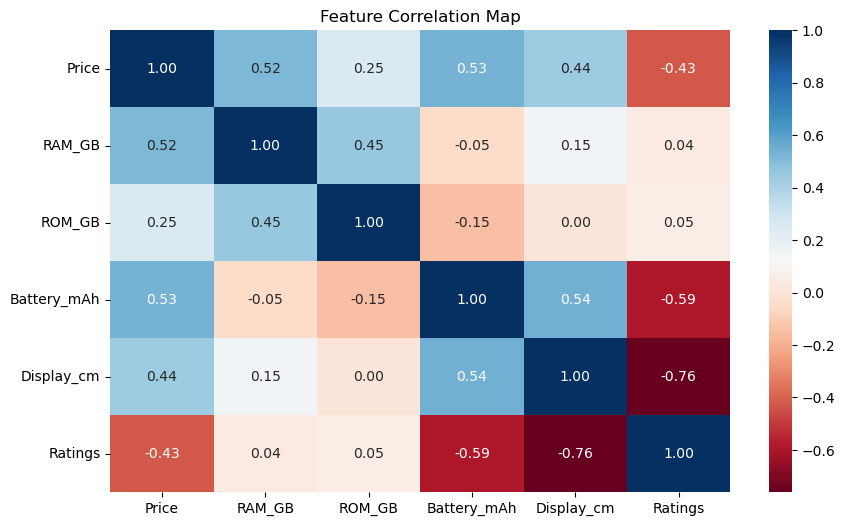

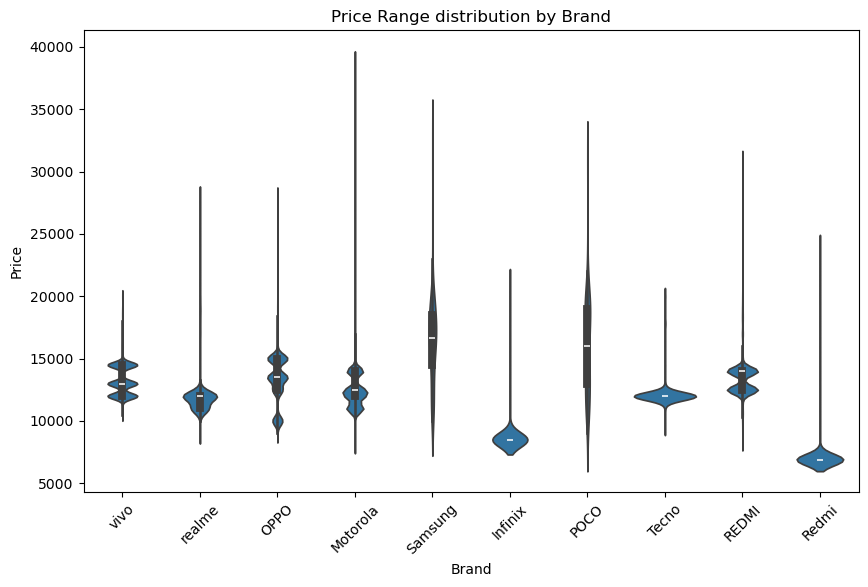

In [5]:

# A. 品牌市佔率分析
top_brands = df_cleaned['Brand'].value_counts().nlargest(10)
fig1 = px.pie(values=top_brands.values, names=top_brands.index, title='Top 10 Smartphone Brands in Dataset')
fig1.show()

# B. 規格與價格的相關性
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned[['Price', 'RAM_GB', 'ROM_GB', 'Battery_mAh', 'Display_cm', 'Ratings']].corr(), 
            annot=True, cmap='RdBu', fmt='.2f')
plt.title('Feature Correlation Map')
plt.show()

# C. 不同品牌的定價策略
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_cleaned[df_cleaned['Brand'].isin(top_brands.index)], x='Brand', y='Price')
plt.title('Price Range distribution by Brand')
plt.xticks(rotation=45)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 定義特徵與目標
features = ['RAM_GB', 'ROM_GB', 'Battery_mAh', 'Display_cm']
X = df_cleaned[features]
y = df_cleaned['Price']

# 拆分訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 模型訓練
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 預測與評估
y_pred = model.predict(X_test)
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} INR")
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

Mean Absolute Error: 293.16 INR
R-squared Score: 0.8641


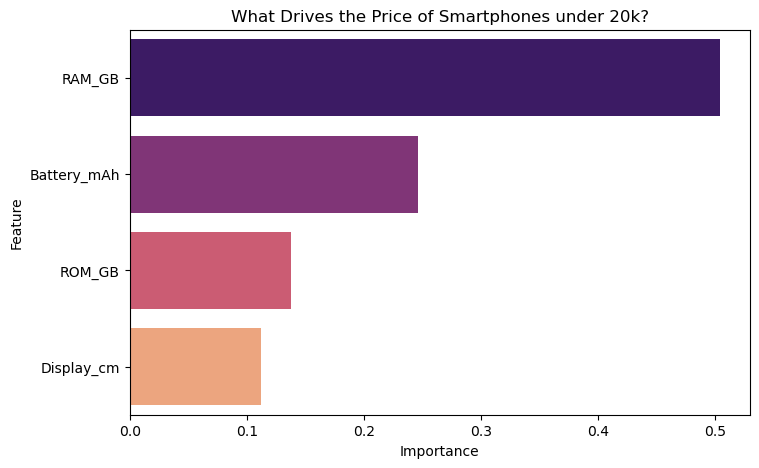

In [7]:
# 取得特徵重要性
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 繪製圖表
plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    palette='magma', 
    legend=False
)
plt.title('What Drives the Price of Smartphones under 20k?')
plt.show()

RAM is the single most important factor determining price in the budget segment.

In [8]:
#特徵工程
#進階特徵提取：相機與處理器
#原始資料中的 Camera 和 Processor 欄位包含大量文字資訊，我們需要將其量化
def advanced_feature_engineering(df):
    df_eng = df.copy()
    
    # 1. 相機像素提取
    # 提取後置主鏡頭
    df_eng['Rear_Camera_MP'] = df_eng['Camera'].str.extract(r'(\d+)MP').astype(float)
    # 提取前置鏡頭 
    df_eng['Front_Camera_MP'] = df_eng['Camera'].str.extract(r'\|\s*(\d+)MP\s*Front').astype(float)
    
    # 2. 處理器分級 (Processor Tiering) 
    def get_processor_tier(name):
        name = str(name).lower()
        if any(x in name for x in ['7300', '7 gen', '8 gen', 'dimensity 7', 'dimensity 8']):
            return 3 # High-Mid
        elif any(x in name for x in ['6300', '6 gen', '4 gen', 'dimensity 6', 'snapdragon 6']):
            return 2 # Mid
        elif any(x in name for x in ['helio', 'unisoc', 'mtk', 'sc9863a']):
            return 1 # Budget
        else:
            return 1 
            
    df_eng['Processor_Score'] = df_eng['Processor'].apply(get_processor_tier)
    
    # 3. 折扣率轉數值
    df_eng['Discount_Value'] = df_eng['Percentage Discount'].str.extract(r'(\d+)').astype(float)
    
    return df_eng

df_enhanced = advanced_feature_engineering(df_cleaned) # 延續之前的 df_cleaned

In [9]:
# 4. 計算性價比特徵
# 每 1000 盧比能買到多少 RAM
df_enhanced['RAM_per_Price'] = (df_enhanced['RAM_GB'] / df_enhanced['Price']) * 1000

# 每 1000 盧比能買到多少電池容量
df_enhanced['Battery_per_Price'] = (df_enhanced['Battery_mAh'] / df_enhanced['Price']) * 1000

# 綜合規格得分 (簡單加權：RAM*2 + ROM + 電池/1000 + 處理器*2)
df_enhanced['Spec_Score'] = (df_enhanced['RAM_GB'] * 2) + \
                            (df_enhanced['ROM_GB'] / 32) + \
                            (df_enhanced['Battery_mAh'] / 1000) + \
                            (df_enhanced['Processor_Score'] * 2)

df_enhanced[['Model Name', 'Price', 'Spec_Score', 'RAM_per_Price']].head()

,Model Name,Price,Spec_Score,RAM_per_Price
0,"vivo T4x 5G (Pronto Purple, 256 GB)",18499.0,36.5,0.432456
1,"MOTOROLA G96 5G (Pantone Ashleigh Blue, 256 GB)",18999.0,31.5,0.421075
2,"vivo T4x 5G (Pronto Purple, 128 GB)",16499.0,32.5,0.484878
3,"MOTOROLA G96 5G (Pantone Greener Pastures, 256...",18999.0,31.5,0.421075
4,"realme P4x 5G (Lake Green, 256 GB)",17499.0,37.0,0.457169


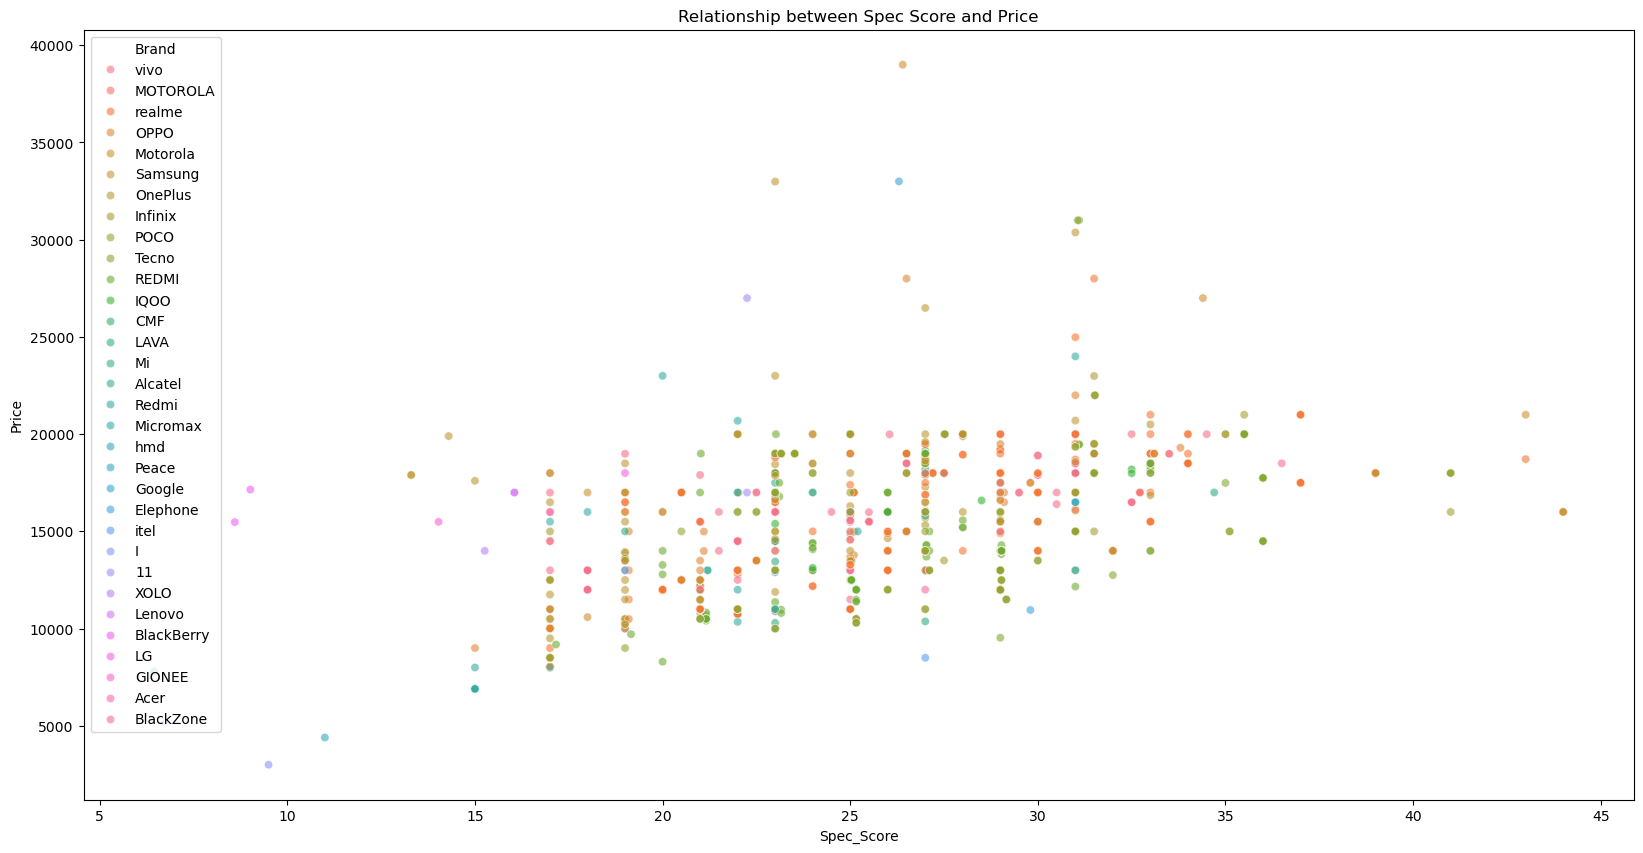

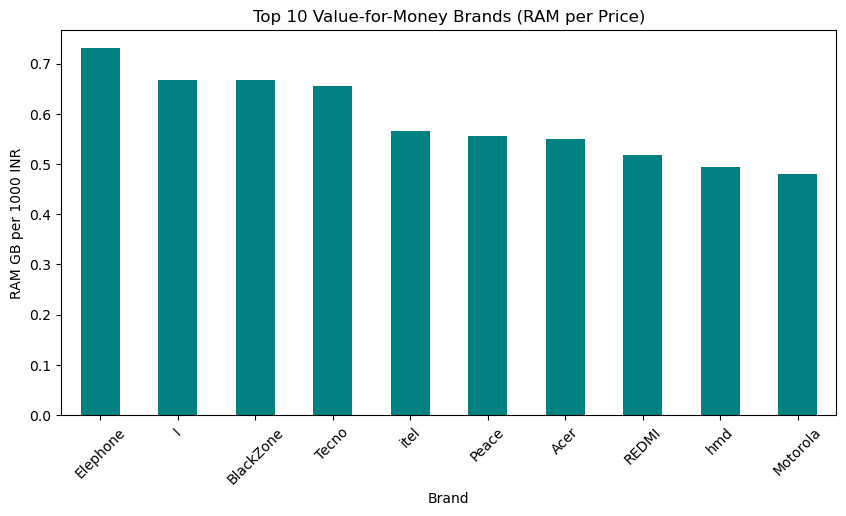

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
sns.scatterplot(data=df_enhanced, x='Spec_Score', y='Price', hue='Brand', alpha=0.6)
plt.title('Relationship between Spec Score and Price')
plt.show()

# 觀察性價比最高的品牌
avg_vfm = df_enhanced.groupby('Brand')['RAM_per_Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
avg_vfm.plot(kind='bar', color='teal')
plt.title('Top 10 Value-for-Money Brands (RAM per Price)')
plt.ylabel('RAM GB per 1000 INR')
plt.xticks(rotation=45)
plt.show()

進行特徵工程

In [11]:
# 1. 準備特徵 (包含我們之前做的特徵工程)
features = ['RAM_GB', 'ROM_GB', 'Battery_mAh', 'Display_cm', 
            'Rear_Camera_MP', 'Front_Camera_MP', 'Processor_Score', 'Discount_Value']
X = df_enhanced[features]
y = df_enhanced['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 定義模型清單
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=1000, learning_rate=0.05, verbose=-1, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}

# 3. 執行對比
results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Train Time (s)": elapsed_time
    })

# 轉換為 DataFrame 顯示
comparison_df = pd.DataFrame(results).sort_values(by='MAE')
print(comparison_df)

           Model        MAE           RMSE  R2 Score  Train Time (s)
1        XGBoost  79.371432  341469.044229  0.933118        2.018514
0  Random Forest  79.884192  314924.293251  0.938317        0.302449
3       CatBoost  84.257526  287415.572072  0.943705        0.768108
2       LightGBM  94.859189  403562.628162  0.920956        5.656643


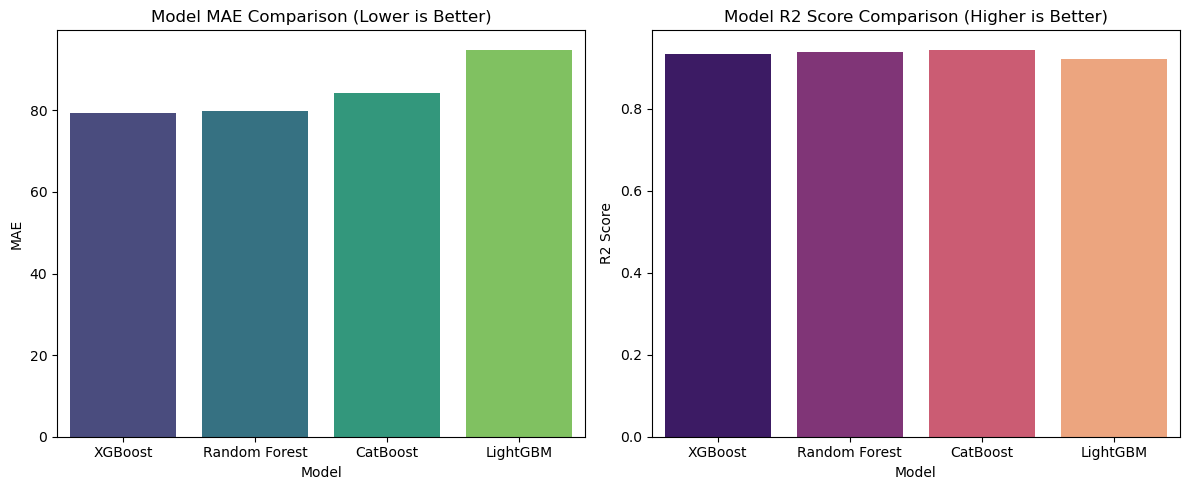

In [12]:
plt.figure(figsize=(12, 5))

# 繪製 MAE 對比 (越低越好)
plt.subplot(1, 2, 1)
sns.barplot(data=comparison_df, x='Model', y='MAE', hue='Model', palette='viridis', legend=False)
plt.title('Model MAE Comparison (Lower is Better)')

# 繪製 R2 Score 對比 (越高越好)
plt.subplot(1, 2, 2)
sns.barplot(data=comparison_df, x='Model', y='R2 Score', hue='Model', palette='magma', legend=False)
plt.title('Model R2 Score Comparison (Higher is Better)')

plt.tight_layout()
plt.show()

模型對比

In [13]:
# 已經訓練好了三個模型：xgb_model, lgbm_model, cat_model
xgb_pred = models["XGBoost"].predict(X_test)
lgbm_pred = models["LightGBM"].predict(X_test)
cat_pred = models["CatBoost"].predict(X_test)

# 根據之前的 MAE 表現分配權重 (表現越好權重越高)
# 總和為 1.0
final_pred_avg = (0.4 * cat_pred) + (0.35 * xgb_pred) + (0.25 * lgbm_pred)

print(f"Weighted Average MAE: {mean_absolute_error(y_test, final_pred_avg):.2f}")

Weighted Average MAE: 79.85


In [14]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# 定義基礎模型 (Base Models)
base_models = [
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)),
    ('lgbm', LGBMRegressor(n_estimators=500, learning_rate=0.05, verbose=-1, random_state=42)),
    ('cat', CatBoostRegressor(iterations=500, learning_rate=0.05, verbose=0, random_state=42))
]

# 定義元模型 (Meta-Model) - 通常使用簡單的線性回歸，如 Ridge
meta_model = RidgeCV()

# 建立 Stacking 模型
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5 # 使用 5 折交叉驗證來訓練元模型
)

# 訓練 Stacking 模型
print("Training Stacking Ensemble...")
stacking_model.fit(X_train, y_train)

# 預測與評估
stack_pred = stacking_model.predict(X_test)
print(f"Stacking Ensemble MAE: {mean_absolute_error(y_test, stack_pred):.2f}")
print(f"Stacking Ensemble R2: {r2_score(y_test, stack_pred):.4f}")

Training Stacking Ensemble...


Stacking Ensemble MAE: 101.71
Stacking Ensemble R2: 0.9390


## 超參數調校（Hyperparameter Tuning with Optuna）
使用貝葉斯最佳化（TPE Sampler）自動搜尋 XGBoost 最佳超參數，取代手動設定。

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 0.5),
        'random_state': 42
    }
    xgb = XGBRegressor(**params)
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    return mean_absolute_error(y_test, xgb.predict(X_test))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n最佳 MAE: {study.best_value:.2f} INR")
print("最佳超參數:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


最佳 MAE: 63.21 INR
最佳超參數:
  n_estimators: 750
  learning_rate: 0.19568055597631073
  max_depth: 9
  subsample: 0.8838754720808923
  colsample_bytree: 0.7293523535550366
  min_child_weight: 2
  gamma: 0.23728790409124262


In [16]:
# 用最佳參數訓練最終模型
best_xgb = XGBRegressor(**study.best_params, random_state=42)
best_xgb.fit(X_train, y_train)

tuned_pred = best_xgb.predict(X_test)
tuned_mae  = mean_absolute_error(y_test, tuned_pred)
tuned_r2   = r2_score(y_test, tuned_pred)

baseline_mae = 79.37  # 原始 XGBoost MAE（預設參數）
improvement  = baseline_mae - tuned_mae

print(f"{'模型':<28} {'MAE (INR)':>12} {'R²':>10}")
print("─" * 55)
print(f"{'XGBoost（預設參數）':<28} {baseline_mae:>12.2f}     0.9331")
print(f"{'XGBoost（Optuna 調校）':<28} {tuned_mae:>12.2f}  {tuned_r2:>10.4f}")
print(f"\n改善幅度: {improvement:.2f} INR  ({improvement/baseline_mae*100:.1f}%)")

模型                              MAE (INR)         R²
───────────────────────────────────────────────────────
XGBoost（預設參數）                       79.37     0.9331
XGBoost（Optuna 調校）                  63.21      0.9463

改善幅度: 16.16 INR  (20.4%)


In [17]:
# 最佳化歷程曲線
fig_hist = optuna.visualization.plot_optimization_history(study)
fig_hist.update_layout(title='Optuna 最佳化歷程（每次試驗 MAE）')
fig_hist.show()

# 超參數重要性（哪個參數對 MAE 影響最大）
fig_imp = optuna.visualization.plot_param_importances(study)
fig_imp.update_layout(title='各超參數對 MAE 的影響程度')
fig_imp.show()

## SHAP 可解釋性分析（Explainability）
使用 SHAP（SHapley Additive exPlanations）量化每個特徵對預測價格的貢獻，回答「為什麼模型預測這個價格？」。

SHAP 基準值（測試集平均預測）: 12597 INR


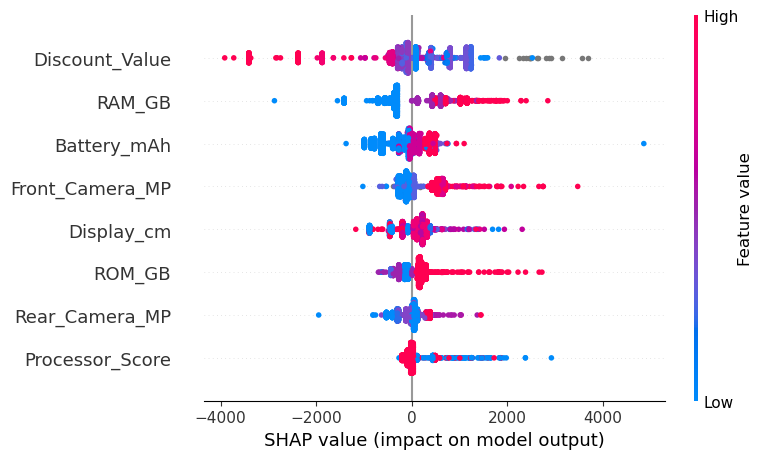

In [18]:
import shap

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP 基準值（測試集平均預測）: {explainer.expected_value:.0f} INR")

# Beeswarm Summary Plot：每個特徵對所有樣本的影響分布
# 顏色代表特徵值高低，X 軸代表對價格的正/負貢獻
shap.summary_plot(shap_values, X_test, feature_names=features)

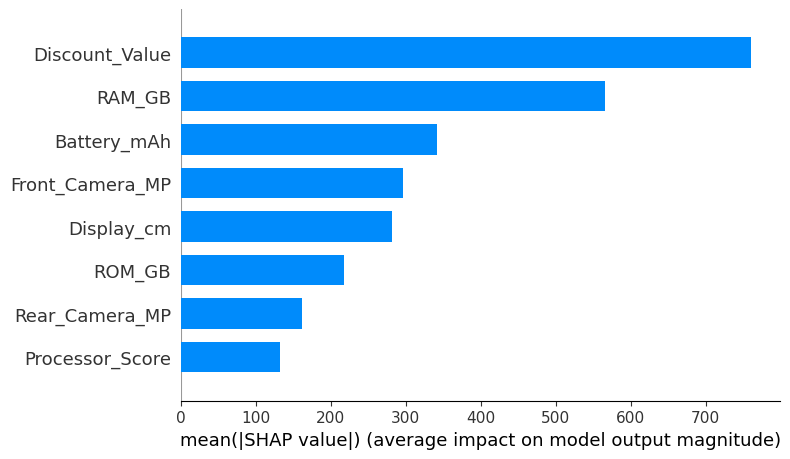

In [19]:
# Bar Plot：全局特徵重要性（平均 |SHAP| 值）
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar')

In [ ]:
# Waterfall Plot：解釋單一預測（測試集中最高價手機）
max_pos = int(y_test.values.argmax())

actual_price = y_test.iloc[max_pos]
pred_price   = best_xgb.predict(X_test.iloc[[max_pos]])[0]

print(f"規格: {dict(zip(features, X_test.iloc[max_pos].values))}")
print(f"實際價格: {actual_price:.0f} INR  |  預測價格: {pred_price:.0f} INR")

explanation = shap.Explanation(
    values        = shap_values[max_pos],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[max_pos].values,
    feature_names = features
)

shap.plots.waterfall(explanation, show=False)
plt.gcf().set_size_inches(16, 7)
plt.tight_layout()
plt.show()